---
title: "How computers add"
subtitle: "Lecture 2: Floating point arithmetic"
abstract-title: Overview
abstract: | 
  (1) Review of last week, </br>
  (2) Whiteboard I (Standard/scientific form; general floating point numbers; underflow, overflow, machine epsilon; Examples: half, single, double precision)
  (3) Half precison = Float16 (<a href='#Float16'>Julia</a>)
  (4) Whiteboard II (round-off error, relative error in floating point representations and the distribution of floating-point numbers; Conditioning, Stability) 
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-warning}

Notes for this lecture have not been updated since we met (stay tuned for updates)

:::

::: {.callout-note}

This lecture is based on Chapter 1 of [Fundamentals of Numerical Computation by Driscoll, Braun] which is avaliable <a href="https://fncbook.com/overview/" 
     class="btn btn-outline-info btn-sm" 
     target="_blank" 
     rel="noopener noreferrer">
    <i class="bi bi-archive me-1" aria-hidden="true"></i>
    online
    <span class="visually-hidden">(opens in a new tab)</span>
  </a>

:::

## Recap

Last time: Admin, Notebooks (Markdown, $\LaTeX$, Julia), Errors, Significant digits, rate of convergence, "seeing" the rate on graphs.

::: {#exr-jam}

In England, when we need to convert between lb and kg some people use the phrase "2.2 pounds of jam is the same as a kilogram". 

- What is the error, absolute error, and relative error of approximating 1 kg with 2.2 lb? 
- To how many significant digits is this approximation correct to?

You may use 1 kg = 2.20462262185 lb.

:::

::: {.callout-tip collapse=true}
# Solution

The error is simply "exact minus approx." $= 2.20462262185 - 2.2 \approx 0.00462262185$. This is also the absolute error (because it is positive).

For the relative error, we divide by the exact value:

In [1]:
x = 2.20462262185 
y = 2.2 

println("relative error = $( (x-y)/x )")

relative error = 0.0020967860005540483


The error is $0.00462262185 \leq 5 \times 10^{-3}$ and so $2.2$ is correct to 3 significant digits. (This is sufficient for all recipes you will likely use).

:::

::: {#exr-marathon}

Most people say a marathon is 26 miles when it is actually 26 miles 385 yards. In Europe, people say a marathon is 42 km when it is actually 42.194988 km.

- Which approximation has a smaller error? 
- What is the advantage of computing the relative errors in this case?

Hint: You may use the fact that 1 mile $=$ 1760 yards. 

:::

::: {.callout-tip collapse=true}
# Solution

A marathon is $26 \times 1760 + 385$ yards. The error and relative error in this approximation is 

In [12]:
x = 26*1760 + 385
y = 26*1760

err, r_err = x-y, (x-y)/x

(385, 0.00834326579261025)

The same calculation for the approximation in km is

In [11]:
x′ = 42.194988
y′ = 42 

err′, r_err′ = x′-y′, (x′-y′)/x′

(0.19498800000000216, 0.004621117560218341)

In [14]:
r_err / r_err′

1.8054649516893149

The approximation in miles has a $1.8\times$ larger relative error than the approximation in km. 

Why is the error in the approximation in miles much larger than $1.8\times$ bigger than the error in the approximation in km?

:::

## Standard/scientific form

::: {#exm-Planck}
# Planck's constant

Planck's constant is $6.62607015 × 10^{-34} \text{m}^2 \text{kg s}^{-1}$.

:::

::: {#exr-AU title="Astronomical Unit"}

The astronomical unit is defined as $1 \text{AU} = 149,597,870,700 \text{m}$. Write this in standard form. 

:::

## Floating point numbers 

There are many different versions of floating point numbers; we will pick one to give general ideas rather than specific details.

For fixed $\ell, k$, we define

$$
\begin{align}
    \mathbb F_{k\ell} := 
    &\Bigg\{ 
        (-1)^s (1 + f) 2^n : f = (0.b_1b_2....b_k)_2, \nonumber\\
        &\qquad\qquad n = c - (2^{\ell-1}-1), \quad c \in \{1,\dots,2^{\ell}-2\}\nonumber
    \Bigg\} \nonumber\\
    %
    &\cup \{\pm0, \pm\infty, \text{NaN}\} \cup \{ \text{subnormal numbers} \} \nonumber 
\end{align}
$$ {eq-floats}

Here, 

* $k$ is the *binary precision*,  
* $s\in \{0,1\}$ is the sign bit, so $(-1)^s$ is the *sign*,  
* $1 + f$ is the *significand*,  
* $f$ is the *mantissa*, also called the *fraction*,  
* $n$ is the *exponent*, belongs to $\{ 2 - 2^{\ell-1}, ...., 2^{\ell-1}-1 \}$,  
* $c$ is the *characteristic*,  
* $2^{\ell-1}-1$ is the *bias*

This is stored in a computer as the following $\ell + k + 1$ bits:

\begin{align} 
    \texttt{bitstring} \quad = \quad s \quad | \quad c \text{ written in binary} \quad | \quad  b_1b_2....b_k
    \nonumber
\end{align} 

***Special values.*** 

When $c = 0$, $\texttt{bitstring}$ represents the number $(-1)^s f \cdot 2^{-(2^{\ell-1} - 1)}$. When $f = 0$, this encodes $\pm 0$ and when $f \not=0$ these are called *subnormal numbers*,

When $c = 2^{\ell}-1$, $\texttt{bitstring}$ represents $\pm \infty$ when $f = 0$ and $\text{NaN}$ when $f\not=0$.

::: {#exr-fp-1}

Write down all the floating point numbers with $k = 2$ in the interval $[1,2)$. What about the interval $[2,4)$? $[2^n,2^{n+1})$? 

:::

::: {.callout-tip collapse=true}
# Hint

There are $2^k$ equally spaced floating point numbers in any interval $[2^n,2^{n+1})$ (as long as $\ell$ is sufficiently large).

:::

*Maximum number* is $2^{2^{\ell-1} -1}( 2 - 2^{-k} ) \approx 2^{2^{\ell-1}}$. If the result of a computation exceeds this value, it is stored as $+\infty$ and we have an ***OVERFLOW*** error,

*Minimum positive (normal) number* is $2^{2-2^{\ell-1}}$. If the result of a computation is between this value and zero, it is stored as $0$ and we have an ***UNDERFLOW*** error,

*Machine precision* is $\epsilon_{\text{mach}} = 2^{-k}$. The next largest float after $1$ is $1 + \epsilon_{\text{mach}}$. 

::: {#exr-fp-3}

Take $k=\ell=2$.

- What number does $0 0 1 1 0$ encode?
- Write the bitstring of $-3.5$.
- What are the maximum and minimum positive numbers and the machine precision in this system?

:::

In the following, we will write $1|\ell|k$ for the number of bits used to represent the sign ($1$), the exponent ($\ell$), and the significand ($k$). 

In practice, we have:  

* ``Float16`` = half precision = $1|5|10$,   
* ``Float32`` = single precision = $1|8|23$, and   
* ``Float64`` = double precision = $1|11|52$,  

::: {#exr-fp-2}

What are the maximum and minimum positive numbers and the machine precision for each of ``Float16``, ``Float32``, and ``Float64``?

:::

## Floating point arithmetic

We now consider a set of floating point numbers $\mathbb F := \mathbb F_{k,\ell}$ and define a function $\mathrm{fl} : \mathbb R \to \mathbb F$ that maps real numbers to (one of) the closest points in $\mathbb F$. 

::: {#thm-fl}

If $x \not= 0$ and $|x| \leq (2-2^{-k}) 2^{2^{\ell-1}-1}$, then 

\begin{align}
    \frac
        {| x - \mathrm{fl}(x) |}
        {|x|} 
    \leq  \frac12 \epsilon_{\rm mach}.
\end{align}

:::

**Proof.** Suppose that $x \in [2^n, 2^{n+1})$. The floats in the interval $[2^n, 2^{n+1})$ are of the form $(1 + z \cdot 2^{-k}) \cdot 2^n$ for $z = 0,\dots,2^{k}-1$. Therefore, consectutive floats are spaced apart by $2^{n-k}$ and since $|x| \geq 2^n$, we have

\begin{align}
    \frac
        {| x - \mathrm{fl}(x) |}
        {|x|} 
    \leq \frac12
    \frac
        {2^{n-k}}
        {|x|} 
    \leq  \frac12 2^{-k} = \frac12 \epsilon_{\rm mach}
\end{align}

## ``Float16`` <a id='Float16'></a>

In Julia you can specify the precision by using ``FloatN()`` where $N = 16, 32,$ or $64$. e.g.

In [7]:
x = Float16( π );
x == 3.140625;

(1 + 1/2 + 1/16 + 1/128)*2

3.140625

You can see how this is represented in binary using ``bitstring()``:

In [5]:
bs = bitstring( x )

"0100001001001000"

Here, the first bit is the sign and the next 5 bits correspond to the characteristic:

In [8]:
s = parse(Int, bs[1:1], base=2);
c = parse(Int, bs[2:6], base=2);
@show ( s, c );

(s, c) = (0, 16)


The final bits ``bs[7:16]`` $:= b_1b_2 ... b_{10}$ represent the significand/mantissa in the following way 

\begin{align}
f &= \big(0 . b_1 b_2 b_3 b_4 b_5 b_6 b_7 b_8 b_9 b_{10}\big)_2 \nonumber\\
%
&= \sum_{i=1}^{10} b_i 2^{-i}
\end{align}

That is, ``bs[7:16]`` is $2^{10} \times$ larger than $f$:

In [ ]:
f = 2^(-10) * parse(Int, bs[7:16], base=2)

0.5703125

In [67]:
# exponent is c - 15 (characteristic minus bias)
# significand is 1 + f
[ exponent(x), significand(x) ]

2-element Vector{Float16}:
 1.0
 1.57

In [68]:
y = (-1)^s * 2.0^( c - 15 ) * ( 1 + f )

3.140625

Recall that ``x = Float16( pi )``

In [69]:
x == y

true

## Errors in ``Float16``

In [1]:
using Plots 
using LaTeXStrings 

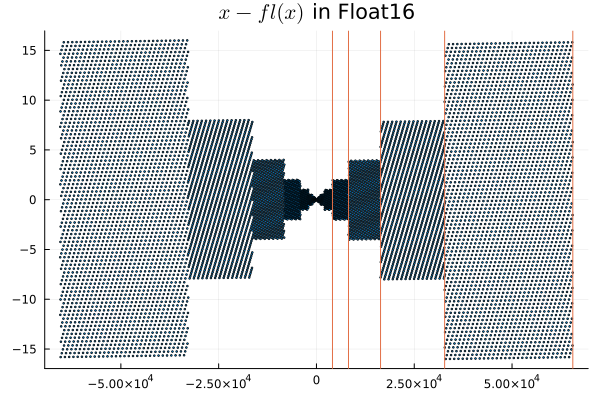

In [72]:
ϵ = eps( Float16 );
x = range( -2.0^(16), 2.0^(16), 10000 ); 
y = @. ( ( x - Float16(x) ) );

plot( x , y,  seriestype=:scatter, ms=1, title=L"$x - fl(x)$ in Float16", legend=false)
vline!( [2.0^n for n in 12:1:16] )

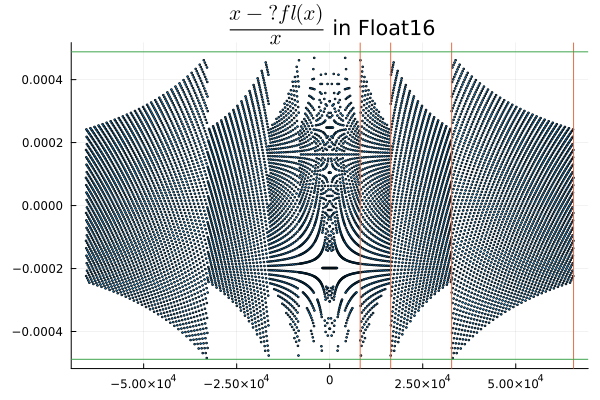

In [ ]:
ϵ = eps( Float16 );
x = range( -2^(16), 2^(16), 10000 ); 
y = @. ( ( x - Float16(x) ) /x );

scatter( x , y; 
    ms=1, title=L"$\frac{x - \text{fl}(x)}{x}$ in Float16", legend=false)
vline!( [2.0^n for n in 13:1:16] )
hline!( [-ϵ/2, ϵ/2] )

***Special values:***

In [74]:
a = Float16( 0 );
(a, bitstring(a) )

(Float16(0.0), "0000000000000000")

In [82]:
b = -Float16( 0 );
(b, bitstring(b) )

(Float16(-0.0), "1000000000000000")

In [84]:
c = Float16( 1/0 );
(c, bitstring(c) )

(Inf16, "0111110000000000")

In [85]:
c = Float16( -1/0 );
(c, bitstring(c) )

(-Inf16, "1111110000000000")

In [87]:
c = Float16( 0/0 );
(c, bitstring(c) )

(NaN16, "1111111000000000")

By default, Julia uses ``Float64``. We will use this datatype for the remainder of this course.

In [12]:
typeof( 1.0 + π )

Float64

## Subtractive cancellation and conditioning

when adding or subtracting numbers so that the result is much smaller in magnitude. For example, we know $x = -1.0000000000000000000147$ to $23$ significant digits but $x + 1 = 1.47 \times 10^{-22}$ to only $3$ significant digits.

This concept can be illustrated using (relative) condition number: suppose we are interested in a quantity $f(x)$ for $x\in \mathbb R$. In practice, we can only store $\widetilde{x} := \mathrm{fl}(x)$ in a computer (recall that $\widetilde{x} = x(1 + \epsilon)$ for some $|\epsilon|\leq \frac12 \epsilon_{\mathrm{mach}}$). Then the ratio of the relative error in the output to the relative error in the input in the limit as the precision goes to zero is known as the *(relative) condition number* $\kappa_f(x)$: 

\begin{align}
\frac
    {\left|\frac
        {f(x) - f(\widetilde{x})}
        {f(x)} \right|}
    {\left|\frac
        {x-\widetilde{x}}
        {x}\right|}
    %
    &= \left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon f(x)}
    \right| \nonumber\\
    %
    &\to \kappa_f(x) \quad \text{as } \epsilon \to 0
\end{align}

That is, the (relative) condition number is approximately the constant of proportionality between the relative error in the output and the relative error of the input:

\begin{align}
    \left|\frac
        {f(x) - f(\widetilde{x})}
        {f(x)} \right|
    \approx \kappa_f(x) |\epsilon|
\end{align}

::: {#exm-cond-1}

The condition number of $f(x) = x + 1$ is $\kappa_f(x) = \left|\frac{x}{x+1}\right|$. This blows up when $x\approx -1$ which explains subtractive cancellation that we mentioned above.

:::

If the condition number is large, we say the problem is *ill-conditioned* or the problem is badly conditioned.

Notice that 

$$
\begin{align}
    \kappa_f(x) &= \lim_{\epsilon\to0}\left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon f(x)}
    \right| \nonumber\\
    %
    &= \lim_{\epsilon\to0}\left|
    \frac
        {f(x) - f(x + \epsilon x)}
        {\epsilon x}
    \right|
    \left| \frac{x}{f(x)} \right| \nonumber\\
    %
    &= \left| \frac{x f'(x)}{f(x)} \right|
\end{align}
$$ {#eq-kappa}

:::{.callout-tip}
# TO-DO

* Assignment 1: Due Wednesday (Install Julia),
* Exercises throughout the notes and below,
* (Sign-up to office hours if you like)

:::

## Exercises

::: {#exm-cond-2}

Compute the relative condition numbers of (i) $x \mapsto cx$ for $c \not= 0$, (ii) $\log$, (iii) $\exp$, (iv) $x^p$, and (v) $f\circ g$ in terms of $\kappa_f$ and $\kappa_g$

:::